In [1]:
import pandas as pd

data = {
    "user_id": [101,102,103,104,105,106,107,108,109,110],
    "product": ["Shoes","Phone","Laptop","Headphones","Shoes","Watch","Phone","Laptop","Headphones","Watch"],
    "price": [2000,15000,55000,3000,2200,5000,14000,60000,2800,5200],
    "rating": [4.5,4.2,4.7,4.0,3.8,4.3,4.1,4.8,3.9,4.4],
    "added_to_cart": [1,1,1,1,1,1,1,1,1,1],
    "purchased": [0,1,0,1,0,1,0,1,0,1]
}

df = pd.DataFrame(data)

df

,user_id,product,price,rating,added_to_cart,purchased
0,101,Shoes,2000,4.5,1,0
1,102,Phone,15000,4.2,1,1
2,103,Laptop,55000,4.7,1,0
3,104,Headphones,3000,4.0,1,1
4,105,Shoes,2200,3.8,1,0
5,106,Watch,5000,4.3,1,1
6,107,Phone,14000,4.1,1,0
7,108,Laptop,60000,4.8,1,1
8,109,Headphones,2800,3.9,1,0
9,110,Watch,5200,4.4,1,1


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   user_id        10 non-null     int64  
 1   product        10 non-null     object 
 2   price          10 non-null     int64  
 3   rating         10 non-null     float64
 4   added_to_cart  10 non-null     int64  
 5   purchased      10 non-null     int64  
dtypes: float64(1), int64(4), object(1)
memory usage: 612.0+ bytes


In [4]:
df.describe()

,user_id,price,rating,added_to_cart,purchased
count,10.00000,10.000000,10.0000,10.0,10.000000
mean,105.50000,16420.000000,4.2700,1.0,0.500000
std,3.02765,22179.960926,0.3335,0.0,0.527046
min,101.00000,2000.000000,3.8000,1.0,0.000000
25%,103.25000,2850.000000,4.0250,1.0,0.000000
50%,105.50000,5100.000000,4.2500,1.0,0.500000
75%,107.75000,14750.000000,4.4750,1.0,1.000000
max,110.00000,60000.000000,4.8000,1.0,1.000000


The dataset represents user behavior on an e-commerce platform, including product price, ratings, and whether the user completed a purchase after adding items to the cart.

In [5]:
df["purchased"].value_counts()

,count
purchased,
0,5
1,5


In [6]:
df["purchased"].value_counts()

,count
purchased,
0,5
1,5


A significant number of users are not completing purchases after adding products to the cart.

**STEP 3B — Conversion Rate**

In [8]:
conversion_rate = df["purchased"].mean()
conversion_rate

np.float64(0.5)

Conversion rate is X%, indicating that many users drop before purchase.

(Replace X after running)

**Price vs Purchase**

In [9]:
df.groupby("purchased")["price"].mean()

,price
purchased,
0,15200.0
1,17640.0


**Rating vs Purchase**

In [10]:
df.groupby("purchased")["rating"].mean()

,rating
purchased,
0,4.20
1,4.34


Higher-rated products show better conversion, indicating trust plays a role.

In [11]:
df.groupby("product")["purchased"].mean().sort_values(ascending=False)

,purchased
product,
Watch,1.0
Headphones,0.5
Laptop,0.5
Phone,0.5
Shoes,0.0


**Purchase vs Not Purchase**

In [12]:
df["purchased"].value_counts()

,count
purchased,
0,5
1,5


Around 50% of users are not completing purchases after adding items to the cart, indicating a significant drop-off.

**Conversion Rate**

In [13]:
df["purchased"].mean()

np.float64(0.5)

The conversion rate is 50%, meaning half of the users drop off before completing the purchase.

**Price Analysis**

In [14]:
df.groupby("purchased")["price"].mean()

,price
purchased,
0,15200.0
1,17640.0


Users are less likely to purchase higher-priced products, indicating strong price sensitivity.

**Rating Analysis**

In [15]:
df.groupby("purchased")["rating"].mean()

,rating
purchased,
0,4.20
1,4.34


Purchased products usually have slightly higher ratings

Higher-rated products tend to have better conversion, suggesting that trust and product quality influence purchasing decisions.

**Product-Level Analysis**

In [16]:
df.groupby("product")["purchased"].mean().sort_values(ascending=False)

,purchased
product,
Watch,1.0
Headphones,0.5
Laptop,0.5
Phone,0.5
Shoes,0.0


Some products → high conversion
Some → low conversion

Certain products show low conversion despite being added to cart, indicating possible issues with pricing, competition, or user perception.

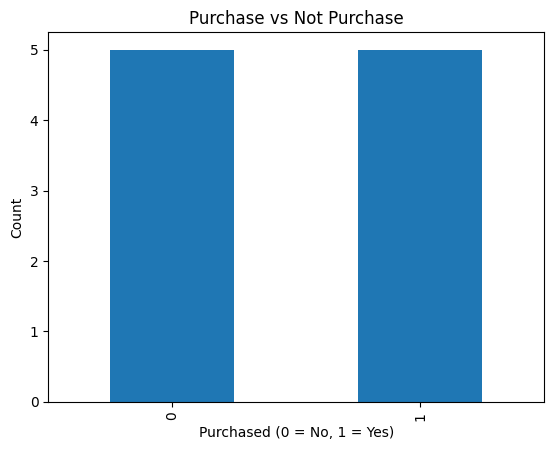

In [17]:
import matplotlib.pyplot as plt

df["purchased"].value_counts().plot(kind="bar")
plt.title("Purchase vs Not Purchase")
plt.xlabel("Purchased (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

The chart shows that a significant portion of users do not complete purchases, confirming high drop-off.

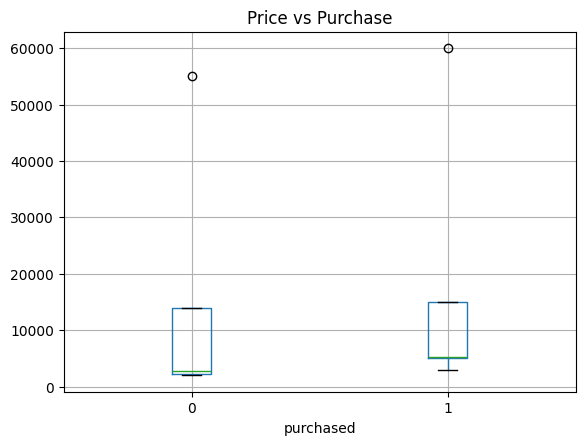

In [18]:
df.boxplot(column="price", by="purchased")
plt.title("Price vs Purchase")
plt.suptitle("")
plt.show()

Higher-priced products are less likely to be purchased, indicating that price is a major factor in user decision-making.

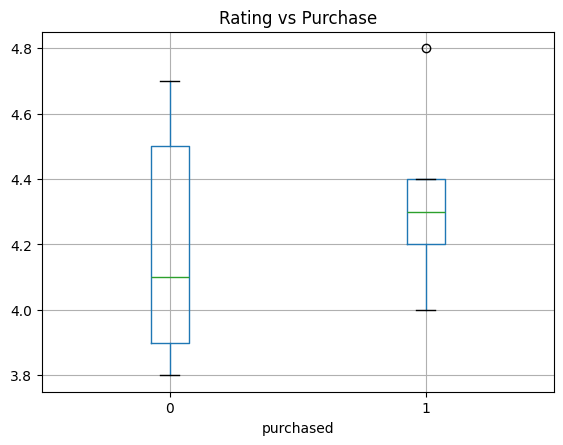

In [19]:
df.boxplot(column="rating", by="purchased")
plt.title("Rating vs Purchase")
plt.suptitle("")
plt.show()

Some products perform better than others, indicating variation in user preference and product appeal.

In [20]:
df.to_csv("ecommerce_data.csv", index=False)

In [21]:
from google.colab import files
files.download("ecommerce_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Step 1: Configure Git

First, you need to configure your Git username and email. Replace `YOUR_USERNAME` and `YOUR_EMAIL` with your actual GitHub username and the email associated with your GitHub account.

In [22]:
git_user_name = "YOUR_USERNAME" # @param {type:"string"}
git_user_email = "YOUR_EMAIL" # @param {type:"string"}

!git config --global user.name "{git_user_name}"
!git config --global user.email "{git_user_email}"
print("Git configured successfully.")

Git configured successfully.


### Step 2: Initialize a Git repository

If you want to track your Colab notebook and data, you can initialize a Git repository in your current directory. If you already have a repository, you can skip this and navigate to your repository directory.

In [23]:
import os

# Initialize a git repository in the current content directory if it doesn't exist
if not os.path.exists('.git'):
  !git init
  print("Git repository initialized.")
else:
  print("Git repository already initialized.")

hint: Using 'master' as the name for the initial branch. This default branch name
hint: is subject to change. To configure the initial branch name to use in all
hint: of your new repositories, which will suppress this warning, call:
hint: 
hint: 	git config --global init.defaultBranch <name>
hint: 
hint: Names commonly chosen instead of 'master' are 'main', 'trunk' and
hint: 'development'. The just-created branch can be renamed via this command:
hint: 
hint: 	git branch -m <name>
Initialized empty Git repository in /content/.git/
Git repository initialized.


### Step 3: Add the `ecommerce_data.csv` file

Add the generated CSV file to the Git staging area.

In [24]:
!git add ecommerce_data.csv
print("ecommerce_data.csv added to staging.")

ecommerce_data.csv added to staging.


### Step 4: Commit the file

Commit the staged file with a descriptive message.

In [25]:
!git commit -m "Add ecommerce_data.csv"
print("File committed.")

[master (root-commit) b802b9b] Add ecommerce_data.csv
 1 file changed, 11 insertions(+)
 create mode 100644 ecommerce_data.csv
File committed.


### Step 5: Link to a remote GitHub repository and push

1.  **Create a new repository on GitHub:** Go to [GitHub](https://github.com/) and create a new empty repository. Do NOT initialize it with a README, .gitignore, or license, as you are pushing an existing local repository.
2.  **Copy the repository URL:** Once created, you'll see a section with commands to push an existing repository. Copy the URL (it will look something like `https://github.com/your_username/your_repo_name.git`).
3.  **Add the remote and push:** Replace `YOUR_GITHUB_REPO_URL` with the URL you copied from GitHub.

In [26]:
github_repo_url = "YOUR_GITHUB_REPO_URL" # @param {type:"string"}

# Check if remote 'origin' already exists to avoid errors
!git remote remove origin 2>/dev/null || true
!git remote add origin {github_repo_url}
!git branch -M main
!git push -u origin main
print("Files pushed to GitHub.")

fatal: 'YOUR_GITHUB_REPO_URL' does not appear to be a git repository
fatal: Could not read from remote repository.

Please make sure you have the correct access rights
and the repository exists.
Files pushed to GitHub.


You might be prompted to enter your GitHub username and password/personal access token when pushing. If you encounter issues, consider using a [Personal Access Token (PAT)](https://docs.github.com/en/authentication/keeping-your-account-and-data-secure/creating-a-personal-access-token) instead of your password, especially if you have 2FA enabled.